In [1]:
import matplotlib
from datascience import *
from datascience import Table
%matplotlib inline
import matplotlib.pyplot as plots
import numpy as np
plots.style.use('fivethirtyeight')

In [2]:
def r_scatter(r):
    plots.figure(figsize=(5,5))
    "Generate a scatter plot with a correlation approximately r"
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    plots.scatter(x, y, color='darkblue', s=20)
    plots.xlim(-4, 4)
    plots.ylim(-4, 4)

## Approach to Prediction

In [3]:
# Note: Child heights are the **adult** heights of children in a family
families = Table.read_table('family_heights-1-1.csv')
families

family,father,mother,child,children,order,sex
1,78.5,67,73.2,4,1,male
1,78.5,67,69.2,4,2,female
1,78.5,67,69,4,3,female
1,78.5,67,69,4,4,female
2,75.5,66.5,73.5,4,1,male
2,75.5,66.5,72.5,4,2,male
2,75.5,66.5,65.5,4,3,female
2,75.5,66.5,65.5,4,4,female
3,75,64,71,2,1,male
3,75,64,68,2,2,female


In [4]:
parent_avgs = (families.column('father') + families.column('mother'))/2

In [5]:
heights = Table().with_columns(
    'Parent Average', parent_avgs,
    'Child', families.column('child'),
)
heights

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5
71,72.5
71,65.5
71,65.5
69.5,71
69.5,68


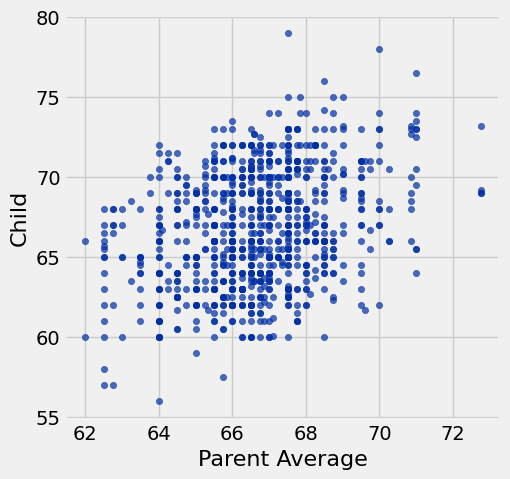

In [6]:
heights.scatter('Parent Average', 'Child')

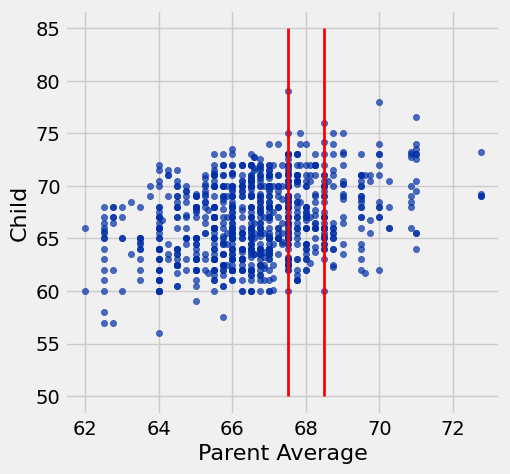

In [7]:
heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2);

In [8]:
nearby = heights.where('Parent Average', are.between(67.5, 68.5))
nearby_mean = np.average(nearby.column('Child'))
nearby_mean

67.620000000000005

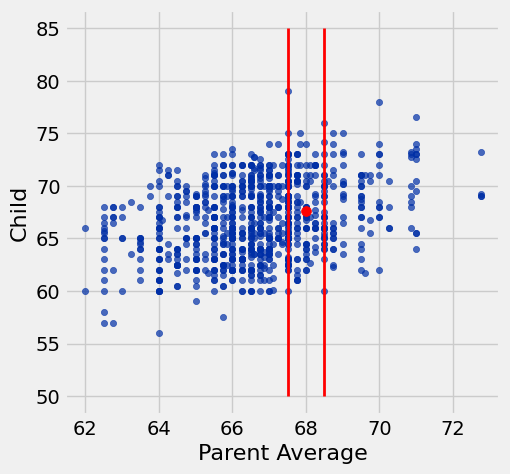

In [9]:
heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plots.scatter(68, nearby_mean, color='red', s=50);

In [10]:
def predict_child(h):
    """Predict the height of a child whose parents have a parent average height of p_avg.
    
    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """
    nearby = heights.where('Parent Average', are.between(h - 1/2, h + 1/2))
    return np.average(nearby.column('Child'))

In [11]:
heights_with_predictions = heights.with_columns(
    'Prediction', heights.apply(predict_child, 'Parent Average'))

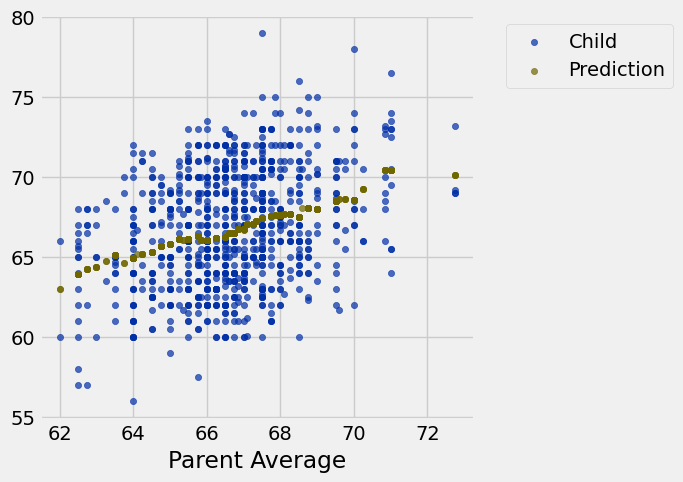

In [12]:
heights_with_predictions.scatter('Parent Average')

## Association

In [13]:
hybrid = Table.read_table('hybrid-1.csv')

In [14]:
hybrid

vehicle,year,msrp,acceleration,mpg,class
Prius (1st Gen),1997,24509.7,7.46,41.26,Compact
Tino,2000,35355,8.2,54.1,Compact
Prius (2nd Gen),2000,26832.2,7.97,45.23,Compact
Insight,2000,18936.4,9.52,53,Two Seater
Civic (1st Gen),2001,25833.4,7.04,47.04,Compact
Insight,2001,19036.7,9.52,53,Two Seater
Insight,2002,19137,9.71,53,Two Seater
Alphard,2003,38084.8,8.33,40.46,Minivan
Insight,2003,19137,9.52,53,Two Seater
Civic,2003,14071.9,8.62,41,Compact


In [15]:
hybrid.sort('msrp', descending=True)

vehicle,year,msrp,acceleration,mpg,class
Lexus LS600h/hL,2007,118544,17.54,21,Midsize
ActiveHybrid 7,2010,104300,20.41,22.11,Large
ActiveHybrid 7i,2011,102606,18.18,20,Midsize
ActiveHybrid X6,2009,97237.9,17.96,18.82,SUV
S400 Long,2009,96208.9,13.89,26.34,Large
Panamera S,2013,96150,18.52,25,Large
Panamera S,2012,95283.9,17.54,25,Large
S400,2013,92350,13.89,21,Large
S400,2010,88212.8,12.99,21,Large
ActiveHybrid 7L,2013,84300,18.18,25,Large


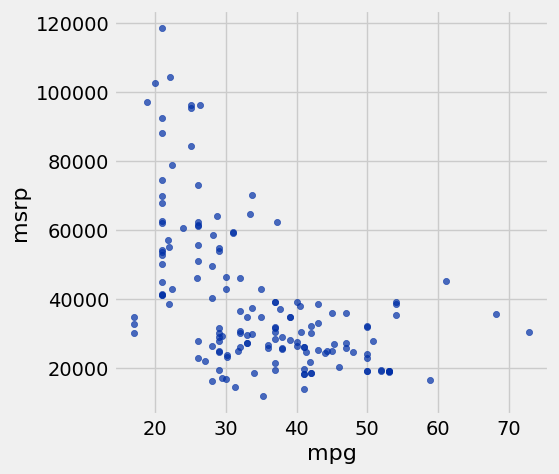

In [16]:
hybrid.scatter('mpg', 'msrp')

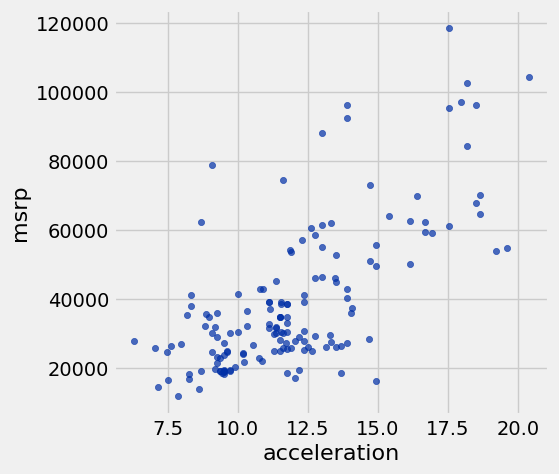

In [17]:
hybrid.scatter('acceleration', 'msrp')

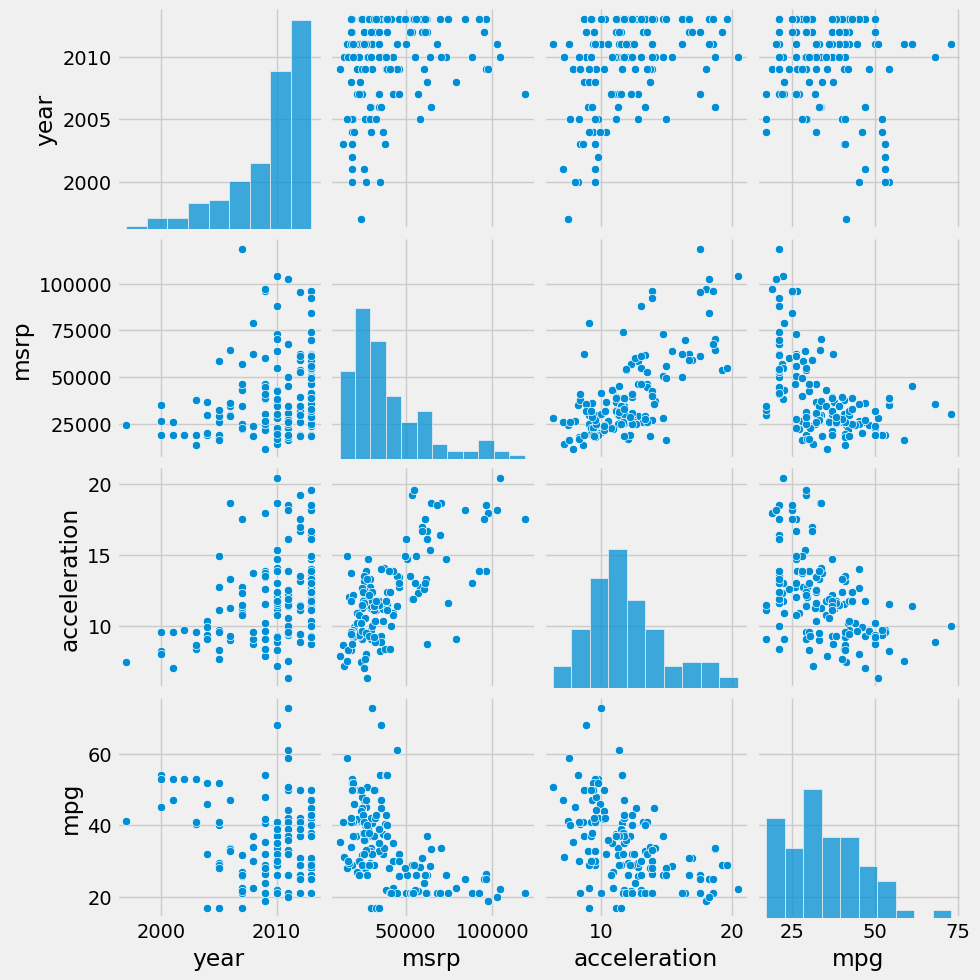

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from datascience import Table

# Load the data
hybrid = Table.read_table('hybrid-1.csv')

# Convert the Table to a pandas DataFrame for use with seaborn
hybrid_df = hybrid.to_df()

# Plot pairwise scatter plots for all numeric columns in the dataset
sns.pairplot(hybrid_df)

# Display the plots
plt.show()


In [19]:
suv = hybrid.where('class', 'SUV')
suv.num_rows

39

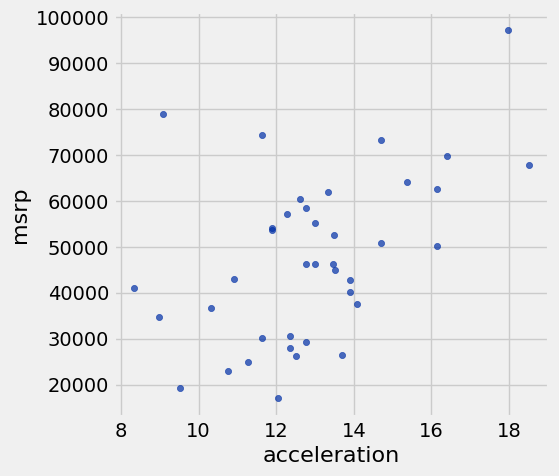

In [20]:
suv.scatter('acceleration', 'msrp')

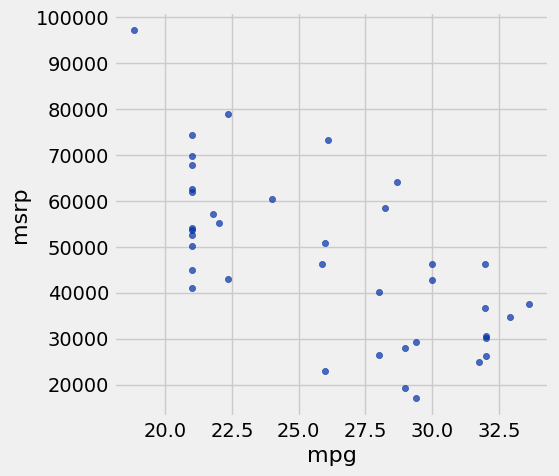

In [21]:
suv.scatter('mpg', 'msrp')

In [22]:
def standard_units(x):
    "Convert any array of numbers to standard units."
    return (x - np.average(x)) / np.std(x)

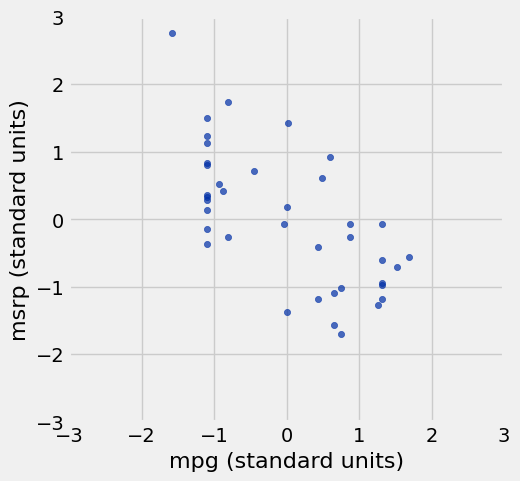

In [23]:
Table().with_columns(
    'mpg (standard units)',  standard_units(suv.column('mpg')), 
    'msrp (standard units)', standard_units(suv.column('msrp'))
).scatter(0, 1)
plots.xlim(-3, 3)
plots.ylim(-3, 3);

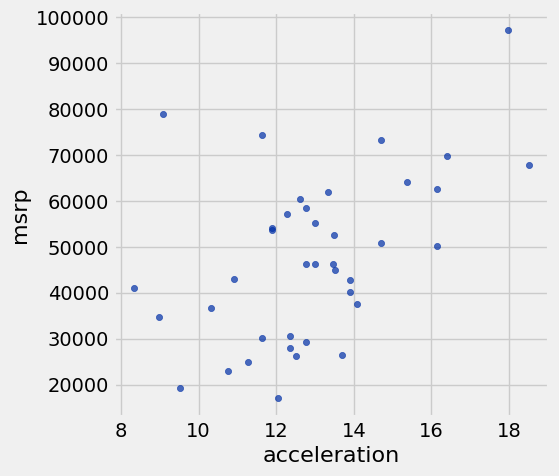

In [24]:
suv.scatter('acceleration', 'msrp')

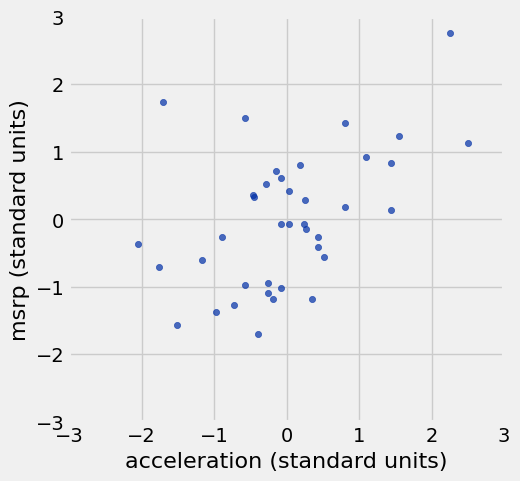

In [25]:
Table().with_columns(
    'acceleration (standard units)', standard_units(suv.column('acceleration')), 
    'msrp (standard units)',         standard_units(suv.column('msrp'))
).scatter(0, 1)
plots.xlim(-3, 3)
plots.ylim(-3, 3);

## Correlation

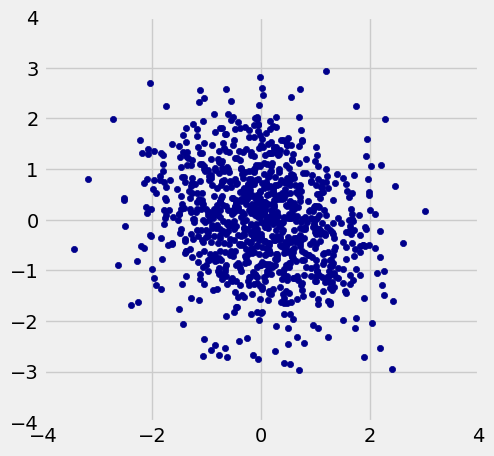

In [26]:
r_scatter(-0.2)

In [27]:
import numpy as np

# Example data arrays
x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 20, 30, 40, 50])

# Calculate the correlation coefficient
correlation_matrix = np.corrcoef(x, y)
correlation_coefficient = correlation_matrix[0, 1]  # Extract the correlation coefficient
print(correlation_coefficient)


1.0


In [28]:
import pandas as pd

# Example data in a DataFrame
data = pd.DataFrame({'x': [1, 2, 3, 4, 5], 'y': [10, 20, 30, 40, 50]})

# Calculate the correlation coefficient between two columns
correlation_coefficient = data['x'].corr(data['y'])
print(correlation_coefficient)


1.0


In [29]:
import pandas as pd

# Load data into a pandas DataFrame
hybrid_df = pd.read_csv('hybrid-1.csv')

# Calculate correlation between 'msrp' and 'mpg'
correlation_coefficient = hybrid_df['msrp'].corr(hybrid_df['mpg'])
correlation_coefficient


-0.53182636336837819

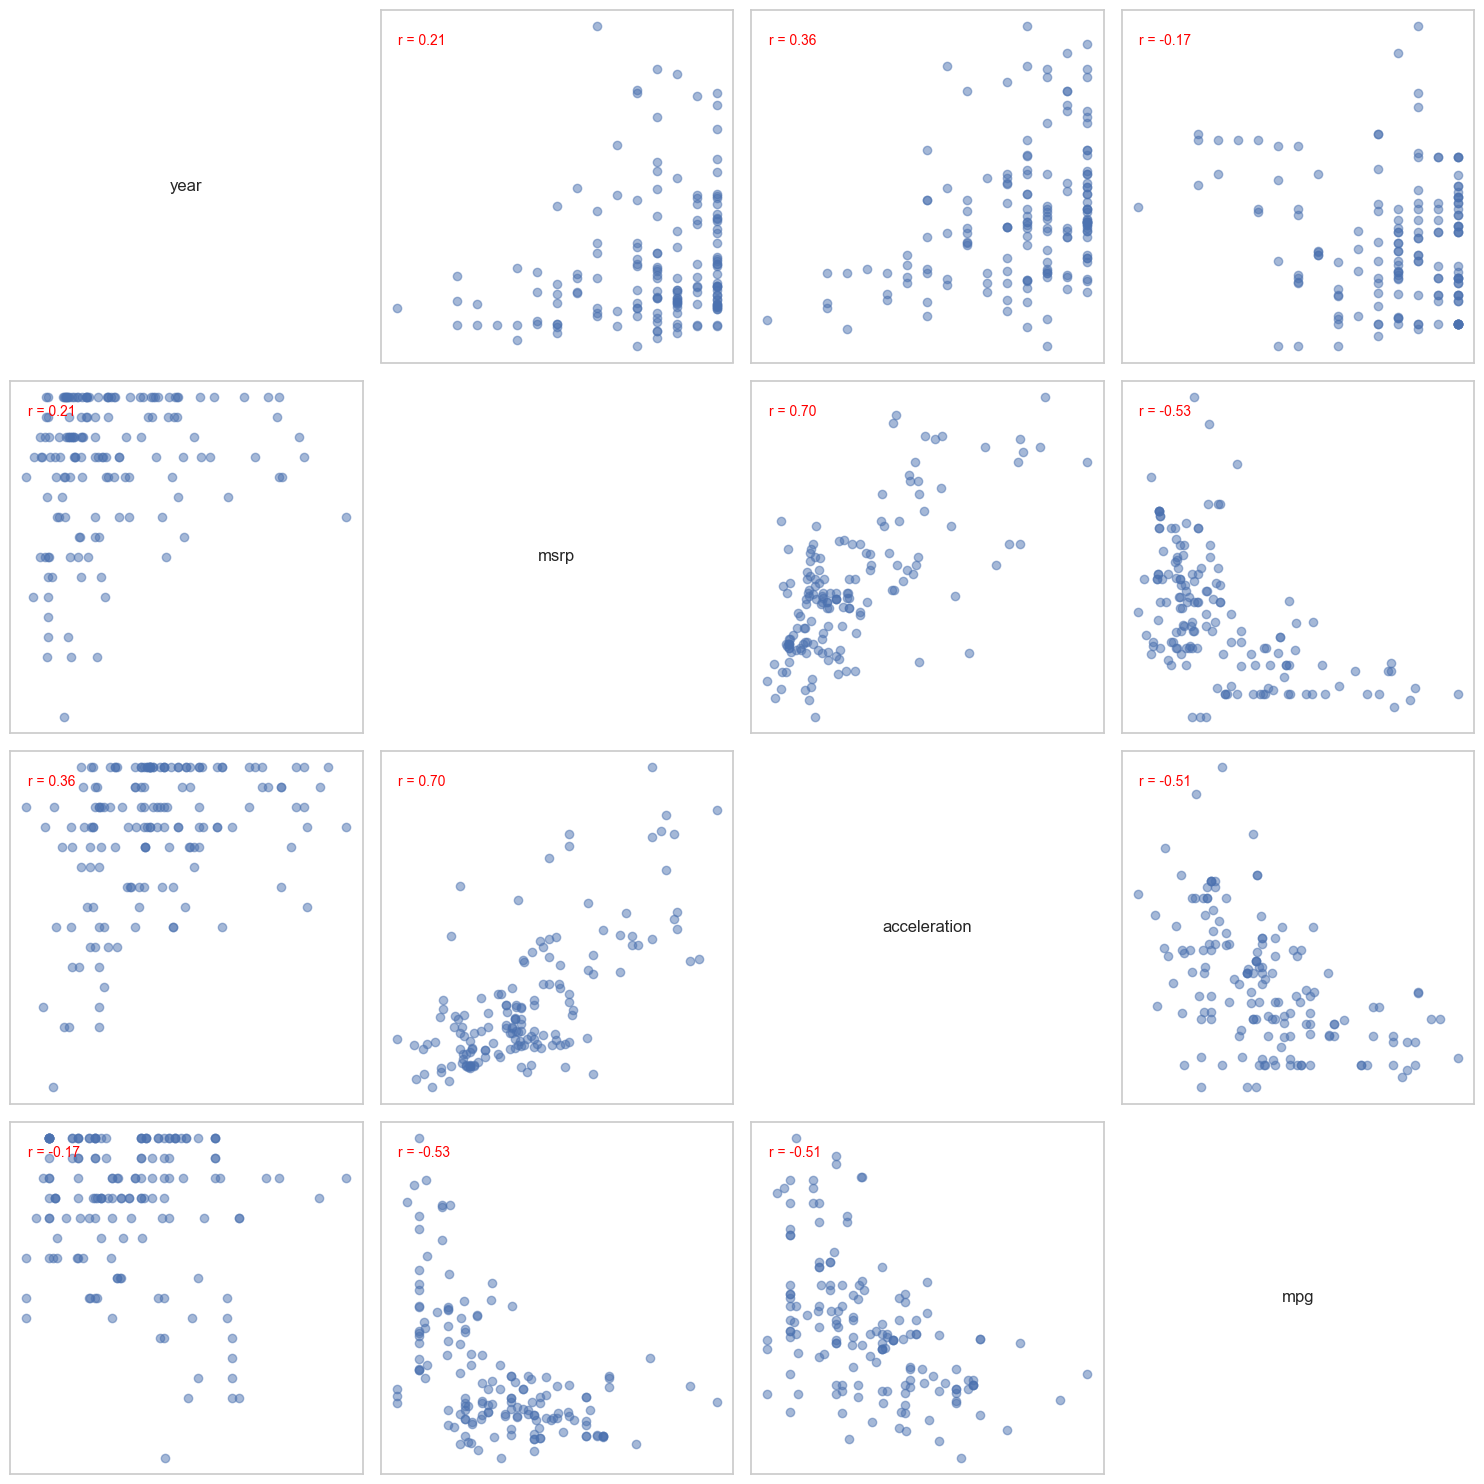

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the hybrid data into a DataFrame
hybrid = pd.read_csv('hybrid-1.csv')

# Select only numeric columns for correlation
numeric_hybrid = hybrid.select_dtypes(include=[float, int])

# Calculate the correlation matrix
corr_matrix = numeric_hybrid.corr()

# Set up a grid of scatter plots with correlation coefficients
sns.set(style="whitegrid")
fig, axes = plt.subplots(len(corr_matrix.columns), len(corr_matrix.columns), figsize=(15, 15))

for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if i == j:
            # Diagonal: Display the variable name
            axes[i, j].text(0.5, 0.5, col1, fontsize=12, ha='center', va='center')
            axes[i, j].set_axis_off()
        else:
            # Scatter plot for each pair of variables
            axes[i, j].scatter(numeric_hybrid[col1], numeric_hybrid[col2], alpha=0.5)
            # Display the correlation coefficient in the plot
            corr_value = corr_matrix.loc[col1, col2]
            axes[i, j].text(0.05, 0.9, f"r = {corr_value:.2f}", transform=axes[i, j].transAxes, fontsize=10, color="red")
        
        # Remove ticks for a cleaner look
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

# Adjust layout
plt.tight_layout()
plt.show()


### Switching Axes

In [31]:
correlation(t, 'x', 'y')

NameError: name 'correlation' is not defined

In [ ]:
t.scatter('x', 'y', s=30, color='red')

In [ ]:
t.scatter('y', 'x', s=30, color='red')

In [ ]:
correlation(t, 'y', 'x')

### Nonlinearity

In [ ]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = Table().with_columns(
        'x', new_x,
        'y', new_x**2
    )
nonlinear.scatter('x', 'y', s=30, color='r')

In [ ]:
correlation(nonlinear, 'x', 'y')

### Outliers

In [ ]:
line = Table().with_columns(
        'x', make_array(1, 2, 3, 4),
        'y', make_array(1, 2, 3, 4)
    )
line.scatter('x', 'y', s=30, color='r')

In [ ]:
correlation(line, 'x', 'y')

In [ ]:
outlier = Table().with_columns(
        'x', make_array(1, 2, 3, 4, 5),
        'y', make_array(1, 2, 3, 4, 0)
    )
outlier.scatter('x', 'y', s=30, color='r')

In [ ]:
correlation(outlier, 'x', 'y')

### Ecological Correlations

In [ ]:
sat2014 = Table.read_table('sat2014.csv').sort('State')
sat2014

In [ ]:
sat2014.scatter('Critical Reading', 'Math')

In [ ]:
correlation(sat2014, 'Critical Reading', 'Math')